#  Matplotlib for Machine Learning
> What is Matplotlib? 
> Matplotlib is a Python library that lets you draw charts and graphs.  
> In Machine Learning, we use it at every stage — before training, during training, and after training.

In machine learning, we use plots to:
- understand the dataset before training,
- check how features relate to the target,
- spot missing values, imbalance, and unusual patterns,
- and explain model results later.

In this section, we will use the Titanic dataset to replace dummy arrays with real-world data.

## Why should a beginner learn this?
When you build an ML model, you need to answer 3 questions visually:

| When? | Question | Plot used |
|-------|----------|-----------|
| Before modeling| What does my data look like? Any patterns? | Histogram, Bar chart, Scatter |
| After modeling | Where is my model going wrong? | Confusion Matrix |
| During training | Is my model learning or memorizing? | Training Curves |

This notebook teaches you all of these using the Titanic dataset —  
a real dataset about passengers on the Titanic ship.  
Goal: Can we predict who survived? Let's first understand the data visually.

In [15]:
# ============================================================
# STEP 0: Import everything we need
# ============================================================

import matplotlib.pyplot as plt   # for drawing plots
import numpy as np                 # for numbers and arrays
import pandas as pd                # for loading and working with data

In [16]:
# Load a real dataset instead of dummy arrays

# Using Titanic dataset — already present in this repo
import pandas as pd
df = pd.read_csv('../../Various Plots using Matplot,Seaborn,Pandas/train.csv')
#head()-> belongs to numpy and used to load first 5 columns from  used dataset 
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [17]:
# Let's get a quick summary of the data
print("=== Basic Info ===")
print(f"Total passengers: {len(df)}")
print(f"Survived: {df['Survived'].sum()} ({df['Survived'].mean()*100:.1f}%)")
print(f"Did not survive: {len(df) - df['Survived'].sum()}")
print("\n=== Missing Values ===")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\n=== Data Types ===")
print(df.dtypes)

=== Basic Info ===
Total passengers: 891
Survived: 342 (38.4%)
Did not survive: 549

=== Missing Values ===
Age         177
Cabin       687
Embarked      2
dtype: int64

=== Data Types ===
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object


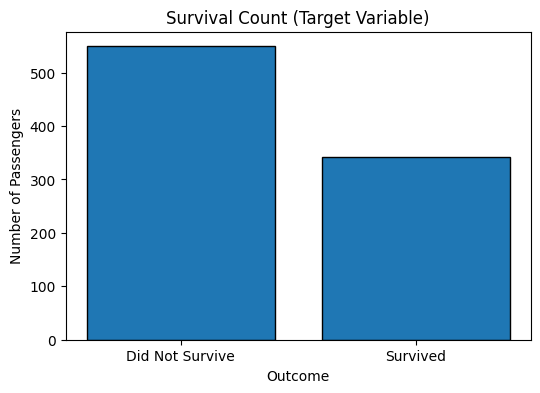

In [18]:
# ============================================================
# Understanding the target variable: Survived
# ============================================================

survival_counts = df['Survived'].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(
    ['Did Not Survive', 'Survived'],
    survival_counts.values,
    edgecolor='black'
)

plt.title('Survival Count (Target Variable)')
plt.xlabel('Outcome')
plt.ylabel('Number of Passengers')

plt.show()

#Why this plot matters in ML

`Survived` is the target variable in this dataset.

This plot helps us answer:
- Is the dataset balanced?
- Will a model be biased toward one class?

Understanding this is important before training any classifier.

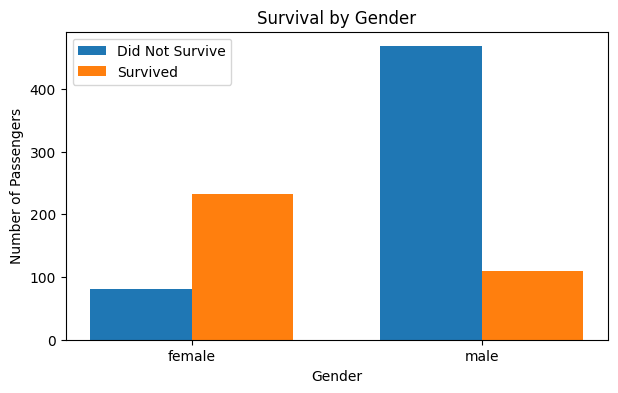

In [19]:
# ============================================================
# Feature vs Target: Gender and Survival
# ============================================================

gender_survival = df.groupby(['Sex', 'Survived']).size().unstack(fill_value=0)

x = range(len(gender_survival.index))
width = 0.35

plt.figure(figsize=(7,4))
plt.bar(x, gender_survival[0], width, label='Did Not Survive')
plt.bar([i + width for i in x], gender_survival[1], width, label='Survived')

plt.xticks([i + width/2 for i in x], gender_survival.index)
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')
plt.title('Survival by Gender')
plt.legend()

plt.show()

# Why this plot matters in ML

Here we check whether **gender affects survival**.

If a feature shows clear separation between classes,  
it is usually useful for machine learning models.

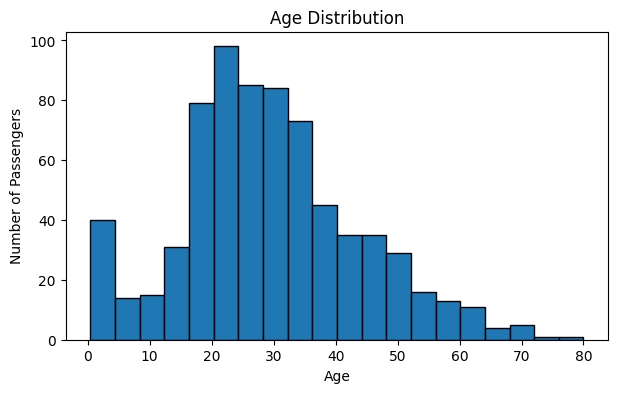

In [20]:
# ============================================================
# Numeric feature distribution: Age
# ============================================================

plt.figure(figsize=(7,4))
plt.hist(df['Age'].dropna(), bins=20, edgecolor='black')

plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.title('Age Distribution')

plt.show()

# Why this plot matters in ML

Histograms help us understand:
- data spread,
- skewness,
- missing values (indirectly).

This affects preprocessing steps like scaling or binning.

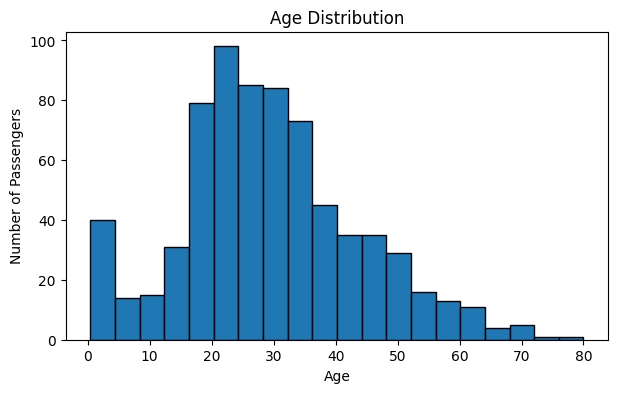

In [21]:
# ============================================================
# Numeric feature distribution: Age
# ============================================================

plt.figure(figsize=(7,4))
plt.hist(df['Age'].dropna(), bins=20, edgecolor='black')

plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.title('Age Distribution')

plt.show()

# Why this plot matters in ML

Histograms help us understand:
- data spread,
- skewness,
- missing values (indirectly).

This affects preprocessing steps like scaling or binning.

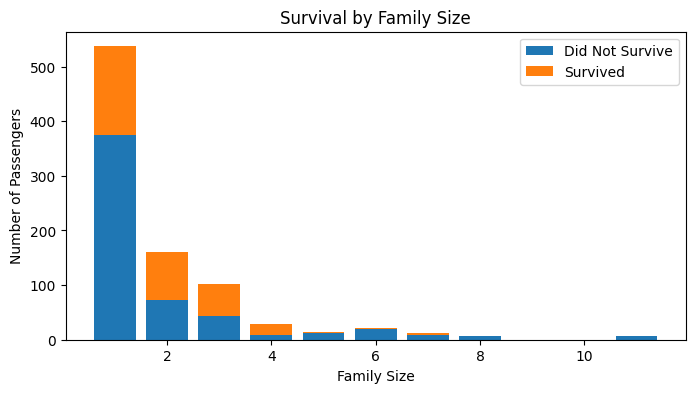

In [22]:
# ============================================================
# Feature engineering example: Family Size
# ============================================================

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

family_survival = df.groupby(['FamilySize', 'Survived']).size().unstack(fill_value=0)

plt.figure(figsize=(8,4))
plt.bar(family_survival.index, family_survival[0], label='Did Not Survive')
plt.bar(family_survival.index, family_survival[1], bottom=family_survival[0], label='Survived')

plt.xlabel('Family Size')
plt.ylabel('Number of Passengers')
plt.title('Survival by Family Size')
plt.legend()

plt.show()

#Why this plot matters in ML

Machine learning often involves **creating new features**.

Here, `FamilySize` is derived from existing columns.
Matplotlib helps us visually verify whether the new feature is useful.

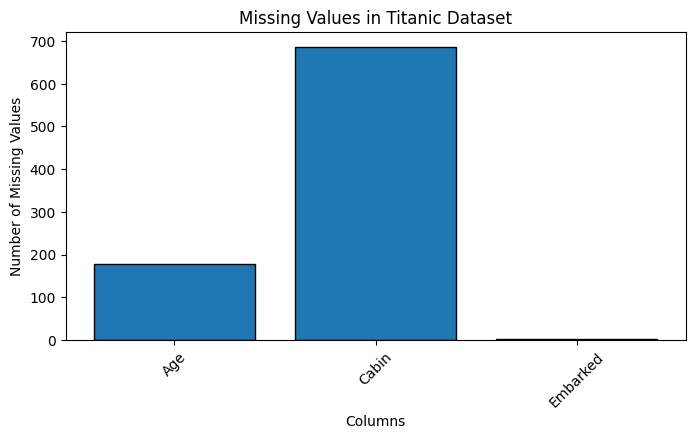

In [23]:
# ============================================================
# Missing values visualization
# ============================================================

missing = df.isnull().sum()
missing = missing[missing > 0]

plt.figure(figsize=(8, 4))
plt.bar(missing.index, missing.values, edgecolor='black')

plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.title('Missing Values in Titanic Dataset')
plt.xticks(rotation=45)
plt.show()

# Why this plot matters in ML

Missing values are one of the first things we check in a dataset.

Before training a model, we may need to:
- fill missing values,
- remove unusable columns,
- or choose better features.

This is an important part of data preprocessing.

## What We Learned from Matplotlib

From these plots, we can see how Matplotlib helps us before building a machine learning model.

We used it to:
- understand the target variable `Survived`,
- compare categories like gender and class,
- inspect numeric features like age,
- and create a new feature called `FamilySize`.
## Conclusion

Matplotlib is not only for drawing graphs.
In machine learning, it helps us understand data before modeling and supports better preprocessing decisions.
This is how plotting becomes useful in ML:
it helps us find patterns, prepare data, and think about which features may matter.